In [25]:
import os

# Physical GPU index. The 5th GPU is index 4.
VISIBLE_GPU = "4"
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = VISIBLE_GPU

print(f"CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']}")
print("Restart the kernel after changing VISIBLE_GPU if torch was already imported.")


CUDA_VISIBLE_DEVICES=4
Restart the kernel after changing VISIBLE_GPU if torch was already imported.


# Position-Wise PCA Contour Landscape

This notebook matches the workflow you described:

1. Fix a prompt.
2. Sample many different full initial states with `base_state = model.initialize_state(embedded_inputs)`.
3. Run the recurrent dynamics for `max_steps`.
4. For each selected position, collect hidden states across all sampled initial states and all steps.
5. PCA those hidden states into 2D.
6. Use residual magnitude `||f_t - f_{t-1}||_2` as the height signal and draw contours.

Important note:
- each position has its own latent state
- but positions are coupled through attention, so trajectories are not independent
- PCA is done separately for each position


In [26]:
from collections import Counter
from pathlib import Path
import importlib
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig

EXAMPLES_DIR = Path("/data/hansen/serv12/HRM-Deq/recurrent-pretraining/examples")
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))

import vis as vis_module
vis_module = importlib.reload(vis_module)

from vis import (
    DEFAULT_PALETTE,
    clean_output_text,
    collect_generated_token_traces,
    collect_next_token_trajectories,
    collect_position_trajectories,
    compact_labels,
    decode_token_ids,
    draw_landscape_with_trajectories,
    find_variable_generated_positions,
    plot_landscape_with_trajectories,
    plot_residual_heatmap,
    project_states_with_pca,
)

assert transformers.__version__.startswith("4.47."), (
    f"This notebook expects transformers 4.47.x, got {transformers.__version__}. "
    "Switch to the 'huginn-venv' kernel."
)

MODEL_DIR = Path("/data/hansen/serv12/HRM-Deq/models/huginn-0125")
DEVICE = "cuda:0"
DTYPE = torch.bfloat16

QUESTION = (
    "There are 15 trees in the grove. Grove workers will plant trees in the grove today. "
    "After they are done, there will be 21 trees. How many trees did the grove workers plant today?"
)
PROMPT_TEXT = f"Q: {QUESTION}\n\nA:"

DEFAULT_SYSTEM_PROMPT = """You are Huginn, an AI assistant who embodies careful thought and deliberation.

Your responses demonstrate:
- Methodical reasoning, breaking complex problems into clear steps
- Mathematical and programming expertise grounded in fundamentals
- The ability to acknowledge uncertainty and correct course when needed
- Clear communication that illuminates rather than just informs
"""

PREVIEW_USE_CHAT_TEMPLATE = True
PREVIEW_SYSTEM_PROMPT = DEFAULT_SYSTEM_PROMPT
PREVIEW_INIT_SCALE = 0.0

RUN_PROFILE = "fast"  # choose from: smoke, fast, balanced, full
PROFILE_CONFIGS = {
    "smoke": {
        "NUM_SAMPLES": 16,
        "SAMPLE_BATCH_SIZE": 4,
        "NUM_STEPS": 8,
        "MAX_TRAJECTORIES_TO_OVERLAY": 6,
        "PLOT_GRID_SIZE": 48,
        "GRID_PAD": 0.10,
        "RBF_SMOOTH": 0.22,
        "WHITEN_COORDS": True,
        "HIDE_AXES": True,
        "SHOW_COLORBAR": True,
        "CONTOUR_LEVEL_COUNT": 8,
        "INIT_STD_SCALE": 4.0,
        "INIT_STD_OVERRIDE": None,
        "FULL_OUTPUT_NUM_STEPS": 8,
        "FULL_OUTPUT_MAX_NEW_TOKENS": 24,
        "SINGLE_TRAJECTORY_POSITION_SLOT": -1,
        "SINGLE_TRAJECTORY_COUNT": 3,
    },
    "fast": {
        "NUM_SAMPLES": 48,
        "SAMPLE_BATCH_SIZE": 8,
        "NUM_STEPS": 16,
        "MAX_TRAJECTORIES_TO_OVERLAY": 10,
        "PLOT_GRID_SIZE": 72,
        "GRID_PAD": 0.10,
        "RBF_SMOOTH": 0.20,
        "WHITEN_COORDS": True,
        "HIDE_AXES": True,
        "SHOW_COLORBAR": True,
        "CONTOUR_LEVEL_COUNT": 10,
        "INIT_STD_SCALE": 12.0,
        "INIT_STD_OVERRIDE": None,
        "FULL_OUTPUT_NUM_STEPS": 12,
        "FULL_OUTPUT_MAX_NEW_TOKENS": 64,
        "SINGLE_TRAJECTORY_POSITION_SLOT": -1,
        "SINGLE_TRAJECTORY_COUNT": 4,
    },
    "balanced": {
        "NUM_SAMPLES": 96,
        "SAMPLE_BATCH_SIZE": 16,
        "NUM_STEPS": 24,
        "MAX_TRAJECTORIES_TO_OVERLAY": 16,
        "PLOT_GRID_SIZE": 96,
        "GRID_PAD": 0.08,
        "RBF_SMOOTH": 0.18,
        "WHITEN_COORDS": True,
        "HIDE_AXES": True,
        "SHOW_COLORBAR": True,
        "CONTOUR_LEVEL_COUNT": 12,
        "INIT_STD_SCALE": 14.0,
        "INIT_STD_OVERRIDE": None,
        "FULL_OUTPUT_NUM_STEPS": 16,
        "FULL_OUTPUT_MAX_NEW_TOKENS": 512,
        "SINGLE_TRAJECTORY_POSITION_SLOT": -1,
        "SINGLE_TRAJECTORY_COUNT": 5,
    },
    "full": {
        "NUM_SAMPLES": 256,
        "SAMPLE_BATCH_SIZE": 32,
        "NUM_STEPS": 64,
        "MAX_TRAJECTORIES_TO_OVERLAY": 24,
        "PLOT_GRID_SIZE": 140,
        "GRID_PAD": 0.08,
        "RBF_SMOOTH": 0.15,
        "WHITEN_COORDS": True,
        "HIDE_AXES": True,
        "SHOW_COLORBAR": True,
        "CONTOUR_LEVEL_COUNT": 16,
        "INIT_STD_SCALE": 16.0,
        "INIT_STD_OVERRIDE": None,
        "FULL_OUTPUT_NUM_STEPS": 32,
        "FULL_OUTPUT_MAX_NEW_TOKENS": 768,
        "SINGLE_TRAJECTORY_POSITION_SLOT": -1,
        "SINGLE_TRAJECTORY_COUNT": 6,
    },
}

if RUN_PROFILE not in PROFILE_CONFIGS:
    raise ValueError(f"Unknown RUN_PROFILE={RUN_PROFILE!r}. Choose from {sorted(PROFILE_CONFIGS)}")

for key, value in PROFILE_CONFIGS[RUN_PROFILE].items():
    globals()[key] = value


SEED = 7
PALETTE = DEFAULT_PALETTE.copy()

torch.manual_seed(SEED)
assert MODEL_DIR.exists(), MODEL_DIR

print(f"RUN_PROFILE = {RUN_PROFILE}")
print(
    {
        "NUM_SAMPLES": NUM_SAMPLES,
        "SAMPLE_BATCH_SIZE": SAMPLE_BATCH_SIZE,
        "NUM_STEPS": NUM_STEPS,
        "PLOT_GRID_SIZE": PLOT_GRID_SIZE,
        "FULL_OUTPUT_NUM_STEPS": FULL_OUTPUT_NUM_STEPS,
        "FULL_OUTPUT_MAX_NEW_TOKENS": FULL_OUTPUT_MAX_NEW_TOKENS,
    }
)

RUN_PROFILE = fast
{'NUM_SAMPLES': 48, 'SAMPLE_BATCH_SIZE': 8, 'NUM_STEPS': 16, 'PLOT_GRID_SIZE': 72, 'FULL_OUTPUT_NUM_STEPS': 12, 'FULL_OUTPUT_MAX_NEW_TOKENS': 64}


In [27]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,
    device_map={"": DEVICE},
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model.eval()

base_init_std = float(model.config.init_values["std"])
analysis_init_std = float(INIT_STD_OVERRIDE) if INIT_STD_OVERRIDE is not None else base_init_std * INIT_STD_SCALE
analysis_init_scale = 0.0 if base_init_std == 0 else analysis_init_std / base_init_std
analysis_effective_std = analysis_init_std * float(getattr(model, "emb_scale", 1.0))

prompt_ids = tokenizer(PROMPT_TEXT, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
embedded_inputs, block_idx = model.embed_inputs(prompt_ids)
prompt_tokens = [tokenizer.decode([tok], skip_special_tokens=False).replace("\n", "\\n") for tok in prompt_ids[0].tolist()]

print(f"prompt length: {prompt_ids.shape[1]}")
print(f"default init std: {base_init_std:.6f}")
print(f"analysis init std: {analysis_init_std:.6f} (scale={analysis_init_scale:.3f})")
print(f"analysis per-dim std after emb_scale: {analysis_effective_std:.6f}")
print()
for i, tok in enumerate(prompt_tokens):
    print(f"{i:>3}: {tok!r}")


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 4/4 [00:07<00:00,  1.77s/it]

prompt length: 50
default init std: 0.008704
analysis init std: 0.104447 (scale=12.000)
analysis per-dim std after emb_scale: 7.589466

  0: 'Q'
  1: ':'
  2: ' There'
  3: ' are'
  4: ' 1'
  5: '5'
  6: ' trees'
  7: ' in'
  8: ' the'
  9: ' g'
 10: 'rove'
 11: '.'
 12: ' G'
 13: 'rove'
 14: ' workers'
 15: ' will'
 16: ' plant'
 17: ' trees'
 18: ' in'
 19: ' the'
 20: ' g'
 21: 'rove'
 22: ' today'
 23: '.'
 24: ' After'
 25: ' they'
 26: ' are'
 27: ' done'
 28: ','
 29: ' there'
 30: ' will'
 31: ' be'
 32: ' 2'
 33: '1'
 34: ' trees'
 35: '.'
 36: ' How'
 37: ' many'
 38: ' trees'
 39: ' did'
 40: ' the'
 41: ' g'
 42: 'rove'
 43: ' workers'
 44: ' plant'
 45: ' today'
 46: '?'
 47: '\\n\\n'
 48: 'A'
 49: ':'


## Full Output Preview

Run a normal greedy decode once so the notebook shows the complete text continuation clearly before the landscape plots. This same generated trace is also reused for the output-token residual heatmap below.

In [28]:
if PREVIEW_USE_CHAT_TEMPLATE:
    preview_messages = []
    if PREVIEW_SYSTEM_PROMPT.strip():
        preview_messages.append({"role": "system", "content": PREVIEW_SYSTEM_PROMPT.strip()})
    preview_messages.append({"role": "user", "content": QUESTION.strip()})
    preview_prompt_text = tokenizer.apply_chat_template(preview_messages, tokenize=False, add_generation_prompt=True)
else:
    preview_prompt_text = PROMPT_TEXT

preview_input_ids = tokenizer(preview_prompt_text, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)

generation_config = GenerationConfig(
    max_new_tokens=FULL_OUTPUT_MAX_NEW_TOKENS,
    stop_strings=["<|end_text|>", "<|end_turn|>"],
    do_sample=False,
    temperature=None,
    top_p=None,
    top_k=None,
    min_p=None,
    return_dict_in_generate=True,
    eos_token_id=65505,
    bos_token_id=65504,
    pad_token_id=65509,
)

generated_trace = collect_generated_token_traces(
    model=model,
    tokenizer=tokenizer,
    input_ids=preview_input_ids.clone(),
    generation_config=generation_config,
    num_steps=FULL_OUTPUT_NUM_STEPS,
    max_new_tokens=FULL_OUTPUT_MAX_NEW_TOKENS,
    init_scale=PREVIEW_INIT_SCALE,
)

generated_token_ids = generated_trace["generated_token_ids"].tolist()
generated_token_labels = decode_token_ids(tokenizer, generated_token_ids, max_chars=24)
generated_step_residual = generated_trace["step_residual_norm"].numpy()

generated_text = clean_output_text(tokenizer.decode(generated_token_ids, skip_special_tokens=False))
full_output_text = clean_output_text(tokenizer.decode(generated_trace["all_input_ids"][0].tolist(), skip_special_tokens=False))

print(f"preview uses chat template: {PREVIEW_USE_CHAT_TEMPLATE}")
print(f"preview init_scale: {PREVIEW_INIT_SCALE}")
print(f"generated_trace step_residual_norm shape: {tuple(generated_trace['step_residual_norm'].shape)}")
print("Prompt:\n")
print(preview_prompt_text)
print("\nGenerated text:\n")
print(generated_text)
print("\nFull decoded output:\n")
print(full_output_text)
print("\nGenerated token labels:\n")
print(generated_token_labels)

preview uses chat template: True
preview init_scale: 0.0
generated_trace step_residual_norm shape: (64, 12)
Prompt:

<|begin_text|><|begin_header|>system<|end_header|>

You are Huginn, an AI assistant who embodies careful thought and deliberation.

Your responses demonstrate:
- Methodical reasoning, breaking complex problems into clear steps
- Mathematical and programming expertise grounded in fundamentals
- The ability to acknowledge uncertainty and correct course when needed
- Clear communication that illuminates rather than just informs<|end_turn|><|begin_header|>user<|end_header|>

There are 15 trees in the grove. Grove workers will plant trees in the grove today. After they are done, there will be 21 trees. How many trees did the grove workers plant today?<|end_turn|><|begin_header|>Huginn<|end_header|>



Generated text:

To determine the number of trees planted by the grove workers today, we can use a simple mathematical approach. Let's denote the number of trees planted by the 

## Find An Unstable Output Token

Scan the generated output positions from left to right. For each output position, keep the reference prefix fixed and resample the recurrent initial state. The scan stops at the first position where the final decoded token is not the same across samples.

In [29]:
SEARCH_NUM_SAMPLES = min(24, NUM_SAMPLES)
SEARCH_BATCH_SIZE = min(8, SAMPLE_BATCH_SIZE)
SEARCH_NUM_STEPS = min(12, max(1, FULL_OUTPUT_NUM_STEPS))
SEARCH_MAX_OUTPUT_POSITIONS = min(24, len(generated_token_ids))
SEARCH_INIT_SCALE = analysis_init_scale
SEARCH_MAX_RESULTS = None

variable_output_positions = find_variable_generated_positions(
    model=model,
    prompt_input_ids=preview_input_ids,
    reference_generated_token_ids=generated_token_ids,
    num_samples=SEARCH_NUM_SAMPLES,
    num_steps=SEARCH_NUM_STEPS,
    init_scale=SEARCH_INIT_SCALE,
    batch_size=SEARCH_BATCH_SIZE,
    max_positions=SEARCH_MAX_OUTPUT_POSITIONS,
    min_unique_tokens=2,
    max_results=SEARCH_MAX_RESULTS,
)

print({
    "SEARCH_NUM_SAMPLES": SEARCH_NUM_SAMPLES,
    "SEARCH_BATCH_SIZE": SEARCH_BATCH_SIZE,
    "SEARCH_NUM_STEPS": SEARCH_NUM_STEPS,
    "SEARCH_MAX_OUTPUT_POSITIONS": SEARCH_MAX_OUTPUT_POSITIONS,
    "SEARCH_INIT_SCALE": float(SEARCH_INIT_SCALE),
})

if not variable_output_positions:
    print("No unstable output positions found in the scanned prefix.")
else:
    print()
    print(f"Found {len(variable_output_positions)} unstable output positions:")
    for unstable in variable_output_positions:
        ref_label = decode_token_ids(tokenizer, [unstable["reference_token_id"]], max_chars=24)[0]
        unique_labels = decode_token_ids(tokenizer, unstable["unique_token_ids"].tolist(), max_chars=24)
        count_values = unstable["counts"].tolist()
        top_pairs = list(zip(unique_labels[:4], count_values[:4]))
        print(
            f"  output_position={unstable['position']}, ",
            f"reference={ref_label!r}, ",
            f"unique={len(unique_labels)}, ",
            f"mode_fraction={unstable['mode_fraction']:.3f}, ",
            f"top={top_pairs}",
            sep="",
        )

{'SEARCH_NUM_SAMPLES': 24, 'SEARCH_BATCH_SIZE': 8, 'SEARCH_NUM_STEPS': 12, 'SEARCH_MAX_OUTPUT_POSITIONS': 24, 'SEARCH_INIT_SCALE': 12.0}

Found 3 unstable output positions:
  output_position=12, reference=' today', unique=2, mode_fraction=0.625, top=[(' today', 15), (',', 9)]
  output_position=16, reference=' use', unique=2, mode_fraction=0.917, top=[(' use', 22), (' follow', 2)]
  output_position=17, reference=' a', unique=2, mode_fraction=0.625, top=[(' a', 15), (' the', 9)]


## Position Selection

Pick which prompt positions to analyze in the PCA landscapes.

In [30]:
selected_positions = [prompt_ids.shape[1] - 4, prompt_ids.shape[1] - 3, prompt_ids.shape[1] - 2, prompt_ids.shape[1] - 1]
selected_labels = [prompt_tokens[p] for p in selected_positions]
focus_slot = SINGLE_TRAJECTORY_POSITION_SLOT % len(selected_positions)

print(list(zip(selected_positions, selected_labels)))
print(f"single-trajectory gallery uses slot={focus_slot}, position={selected_positions[focus_slot]}")


[(46, '?'), (47, '\\n\\n'), (48, 'A'), (49, ':')]
single-trajectory gallery uses slot=3, position=49


## Trajectory Collection

Collect per-step hidden states for the selected prompt positions. These are used for the PCA landscapes below. The output-token heatmap is collected separately from the generated trace above.

In [31]:
trace = collect_position_trajectories(
    model=model,
    embedded_inputs=embedded_inputs,
    block_idx=block_idx,
    positions=selected_positions,
    num_samples=NUM_SAMPLES,
    num_steps=NUM_STEPS,
    init_scale=analysis_init_scale,
    batch_size=SAMPLE_BATCH_SIZE,
)

states = trace["states"]
residual_norms = trace["residual_norms"]
predicted_token_ids = trace["predicted_token_ids"]
predicted_token_labels_per_position = [
    decode_token_ids(tokenizer, predicted_token_ids[:, slot].tolist(), max_chars=24)
    for slot in range(len(selected_positions))
]

focus_counter = Counter(predicted_token_labels_per_position[focus_slot])

print("states:", tuple(states.shape))
print("residual_norms:", tuple(residual_norms.shape))
print("predicted_token_ids:", tuple(predicted_token_ids.shape))
print()
print("Top predicted tokens for the gallery focus position:")
print(focus_counter.most_common(12))


states: (48, 17, 4, 5280)
residual_norms: (48, 16, 4)
predicted_token_ids: (48, 4)

Top predicted tokens for the gallery focus position:
[(' 1', 48)]


In [32]:
pca_per_position = project_states_with_pca(states, whiten_coords=WHITEN_COORDS)
coords_per_position = [entry["coords"].numpy() for entry in pca_per_position]
print(tuple(coords_per_position[0].shape))


(48, 17, 2)


## All-Trajectory Landscapes

One landscape per selected position, with the shared background and many trajectories overlaid.

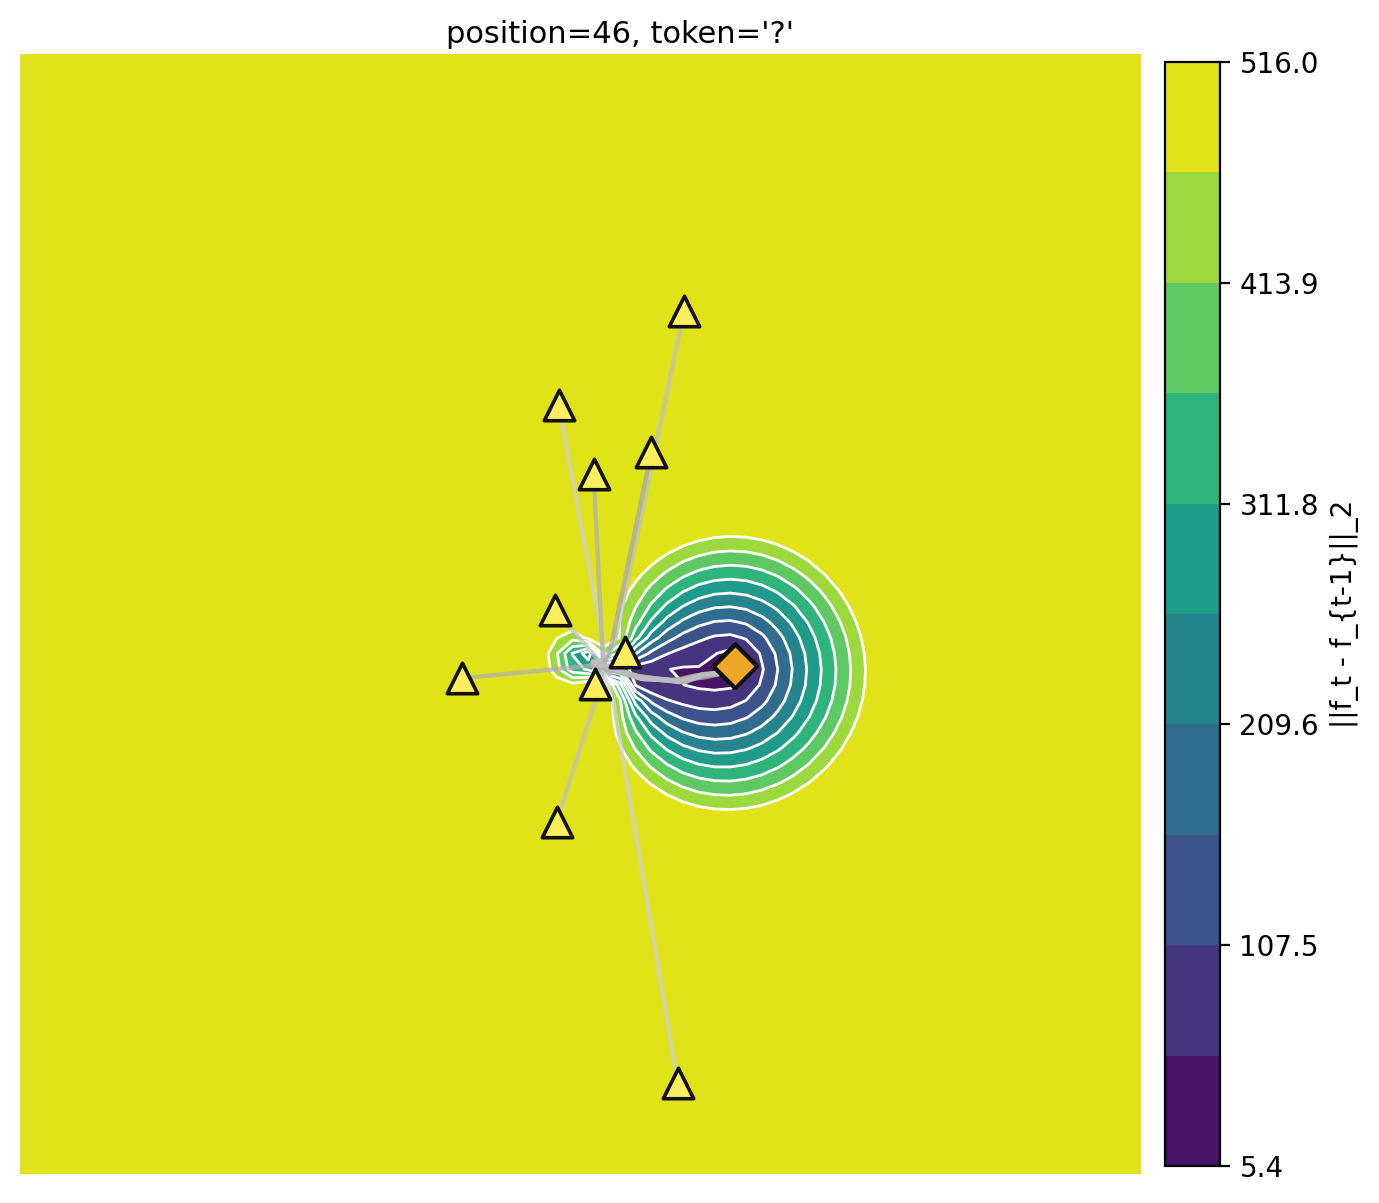

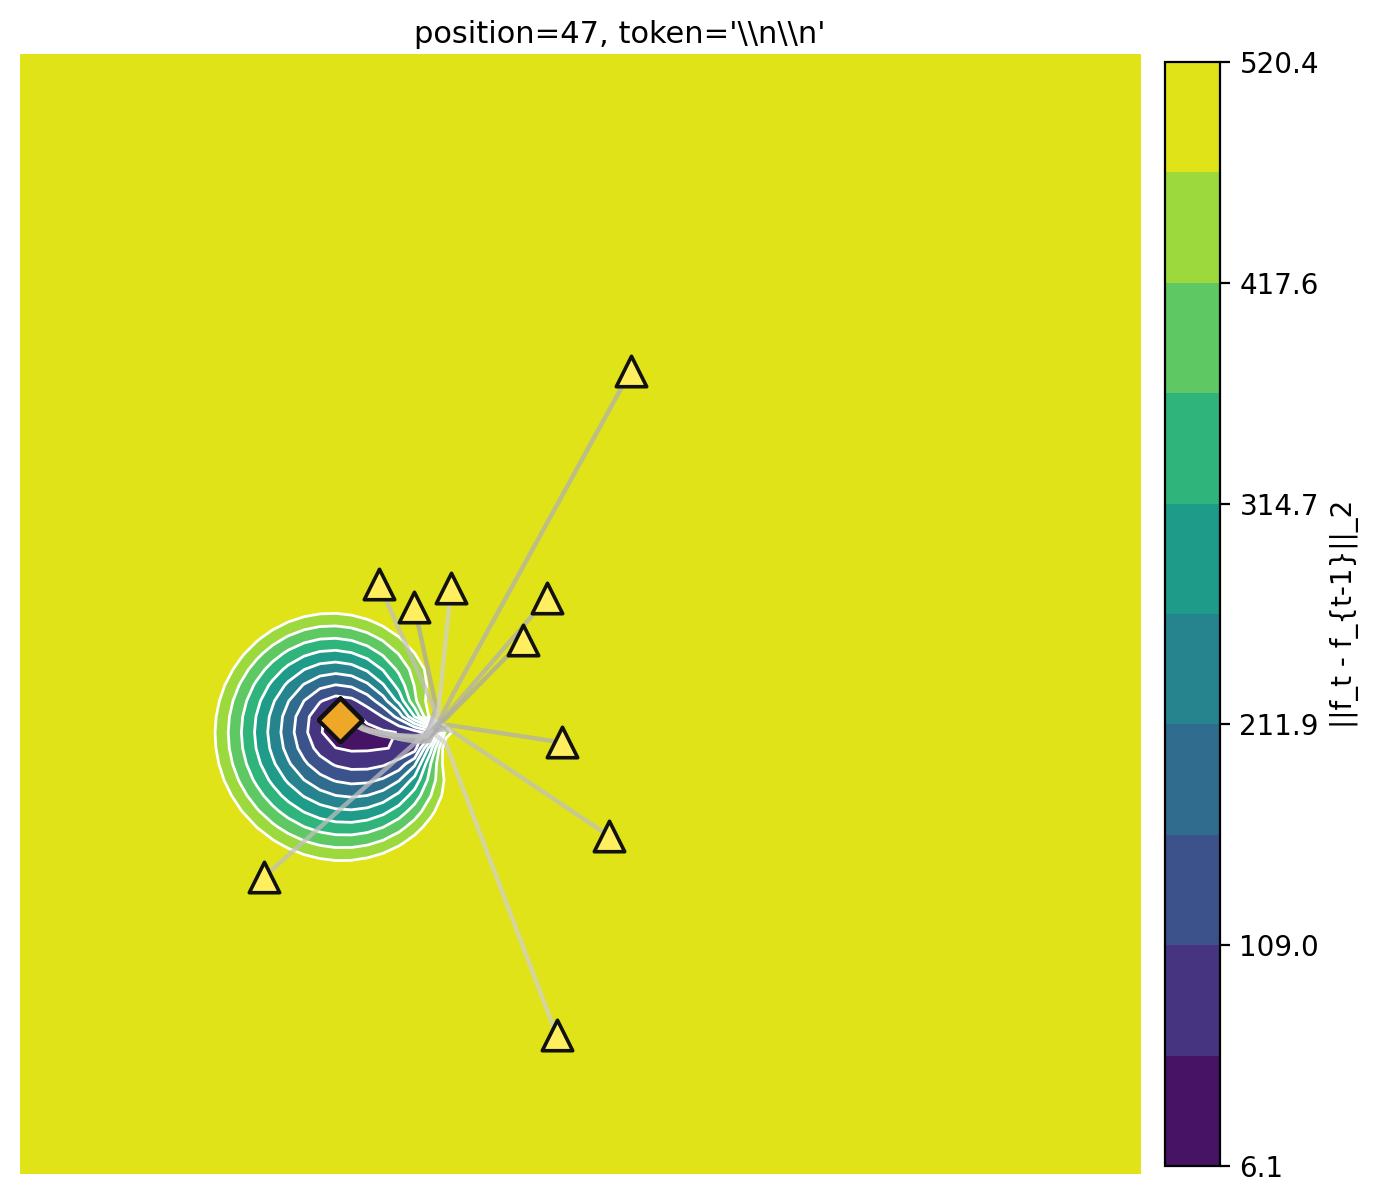

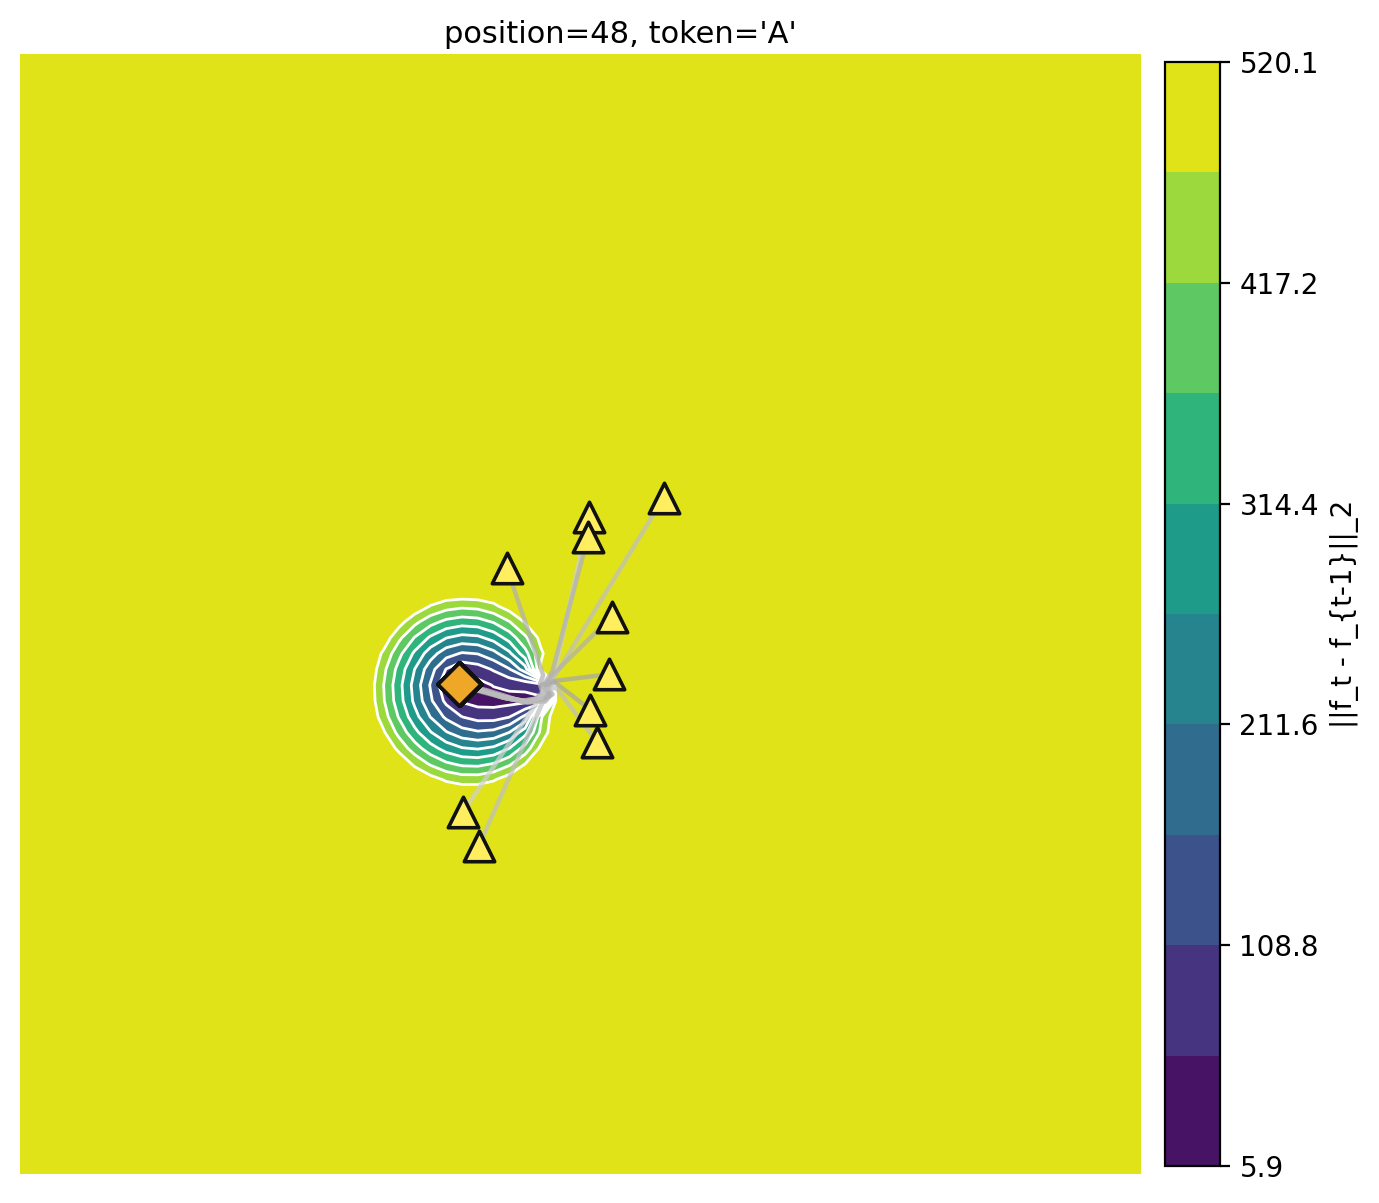

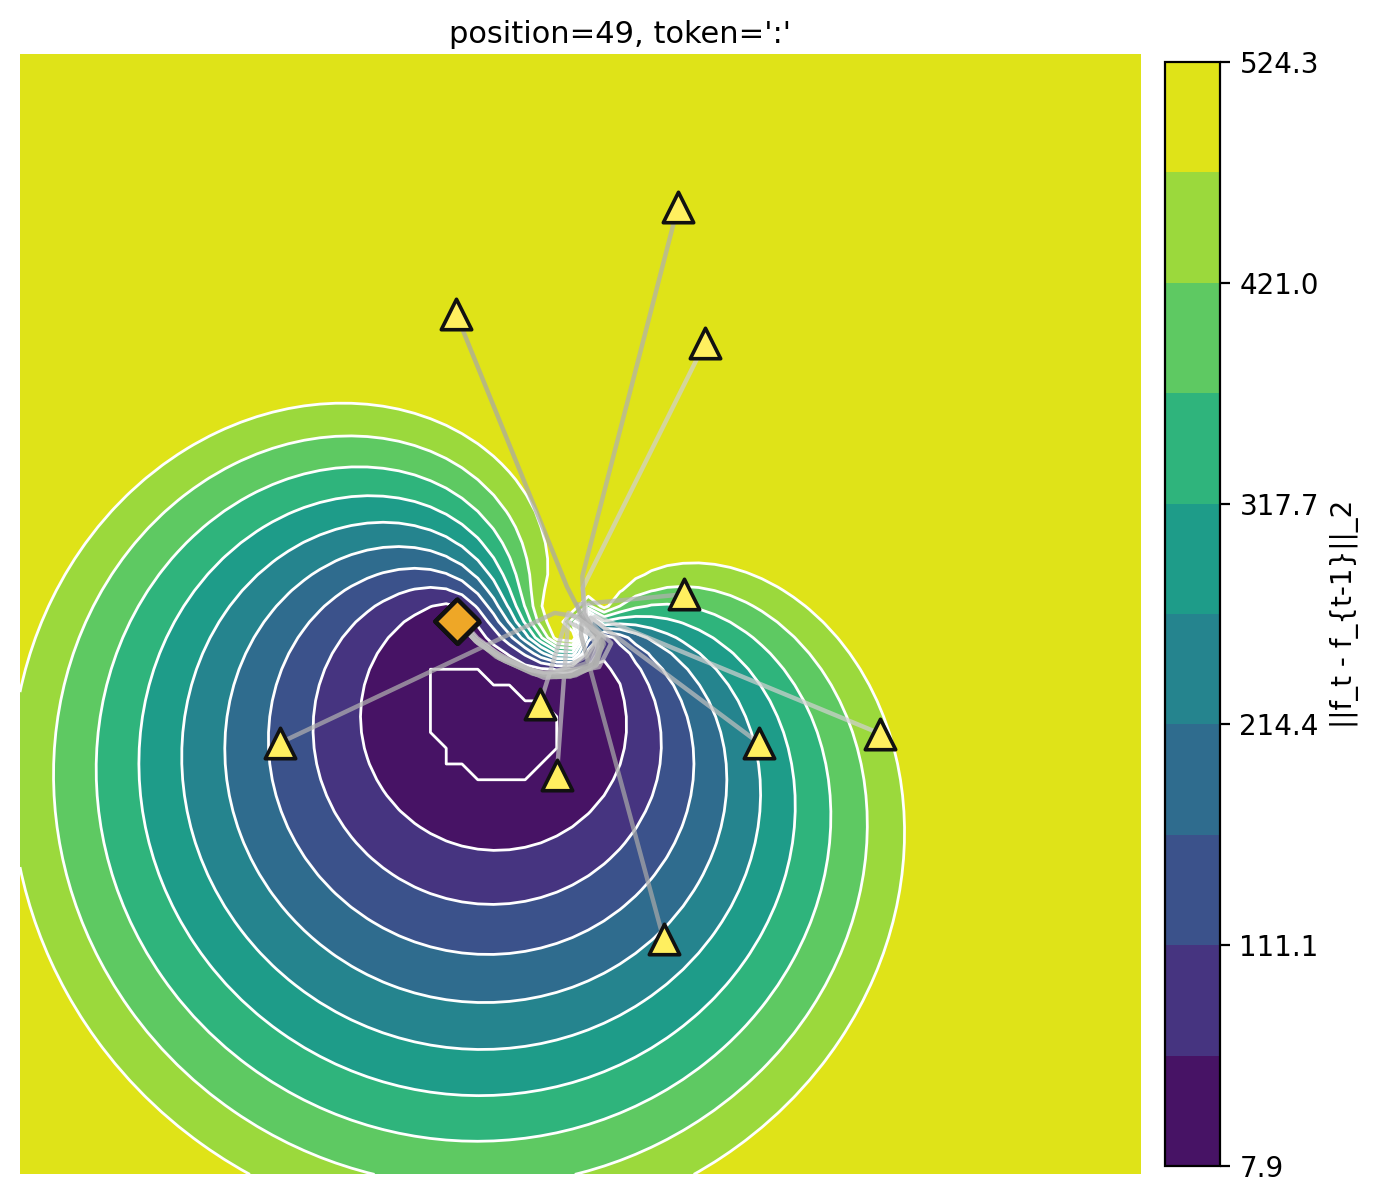

In [33]:
for slot in range(len(selected_positions)):
    title = f"position={selected_positions[slot]}, token={selected_labels[slot]!r}"
    fig, ax = plot_landscape_with_trajectories(
        coords=coords_per_position[slot],
        residuals=residual_norms[:, :, slot].numpy(),
        title=title,
        grid_size=PLOT_GRID_SIZE,
        grid_pad=GRID_PAD,
        smooth=RBF_SMOOTH,
        level_count=CONTOUR_LEVEL_COUNT,
        cmap="viridis",
        hide_axes=HIDE_AXES,
        show_colorbar=SHOW_COLORBAR,
        max_trajectories_to_overlay=MAX_TRAJECTORIES_TO_OVERLAY,
        palette=PALETTE,
    )
    plt.show()


## Output-Token Residual Heatmap

Horizontal axis is generated output token position, vertical axis is recurrent iteration, and color is the residual magnitude `||f_t - f_{t-1}||_2` for that generated token. Context tokens are excluded from this figure.

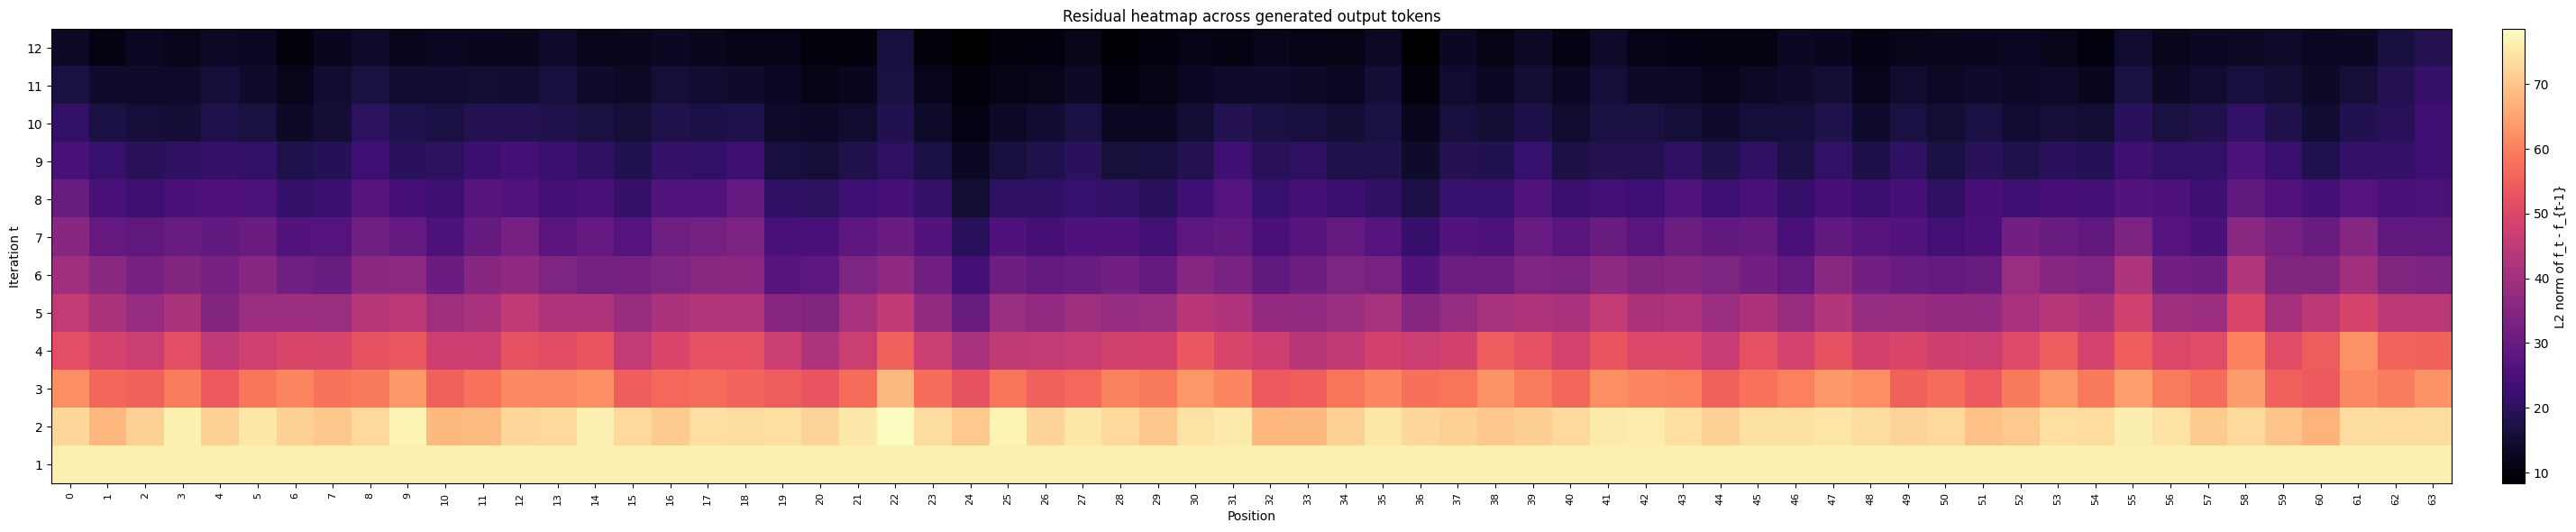

In [34]:
output_token_labels = compact_labels(generated_token_labels, max_chars=12)
fig, ax = plot_residual_heatmap(
    generated_step_residual,
    output_token_labels,
    title="Residual heatmap across generated output tokens",
    cmap="magma",
)
plt.show()


## Single-Trajectory Galleries For All Unstable Output Tokens

For every unstable output position found above, build one shared landscape background for that output token and then overlay a few individual sampled trajectories. The footer below each subplot shows which token that sampled initialization finally decodes to.

{'unstable_positions_to_plot': 3, 'gallery_num_samples': 48, 'gallery_num_steps': 12}

{'unstable_position': 12, 'reference_token': ' today', 'top_tokens': [(' today', 33), (',', 15)]}


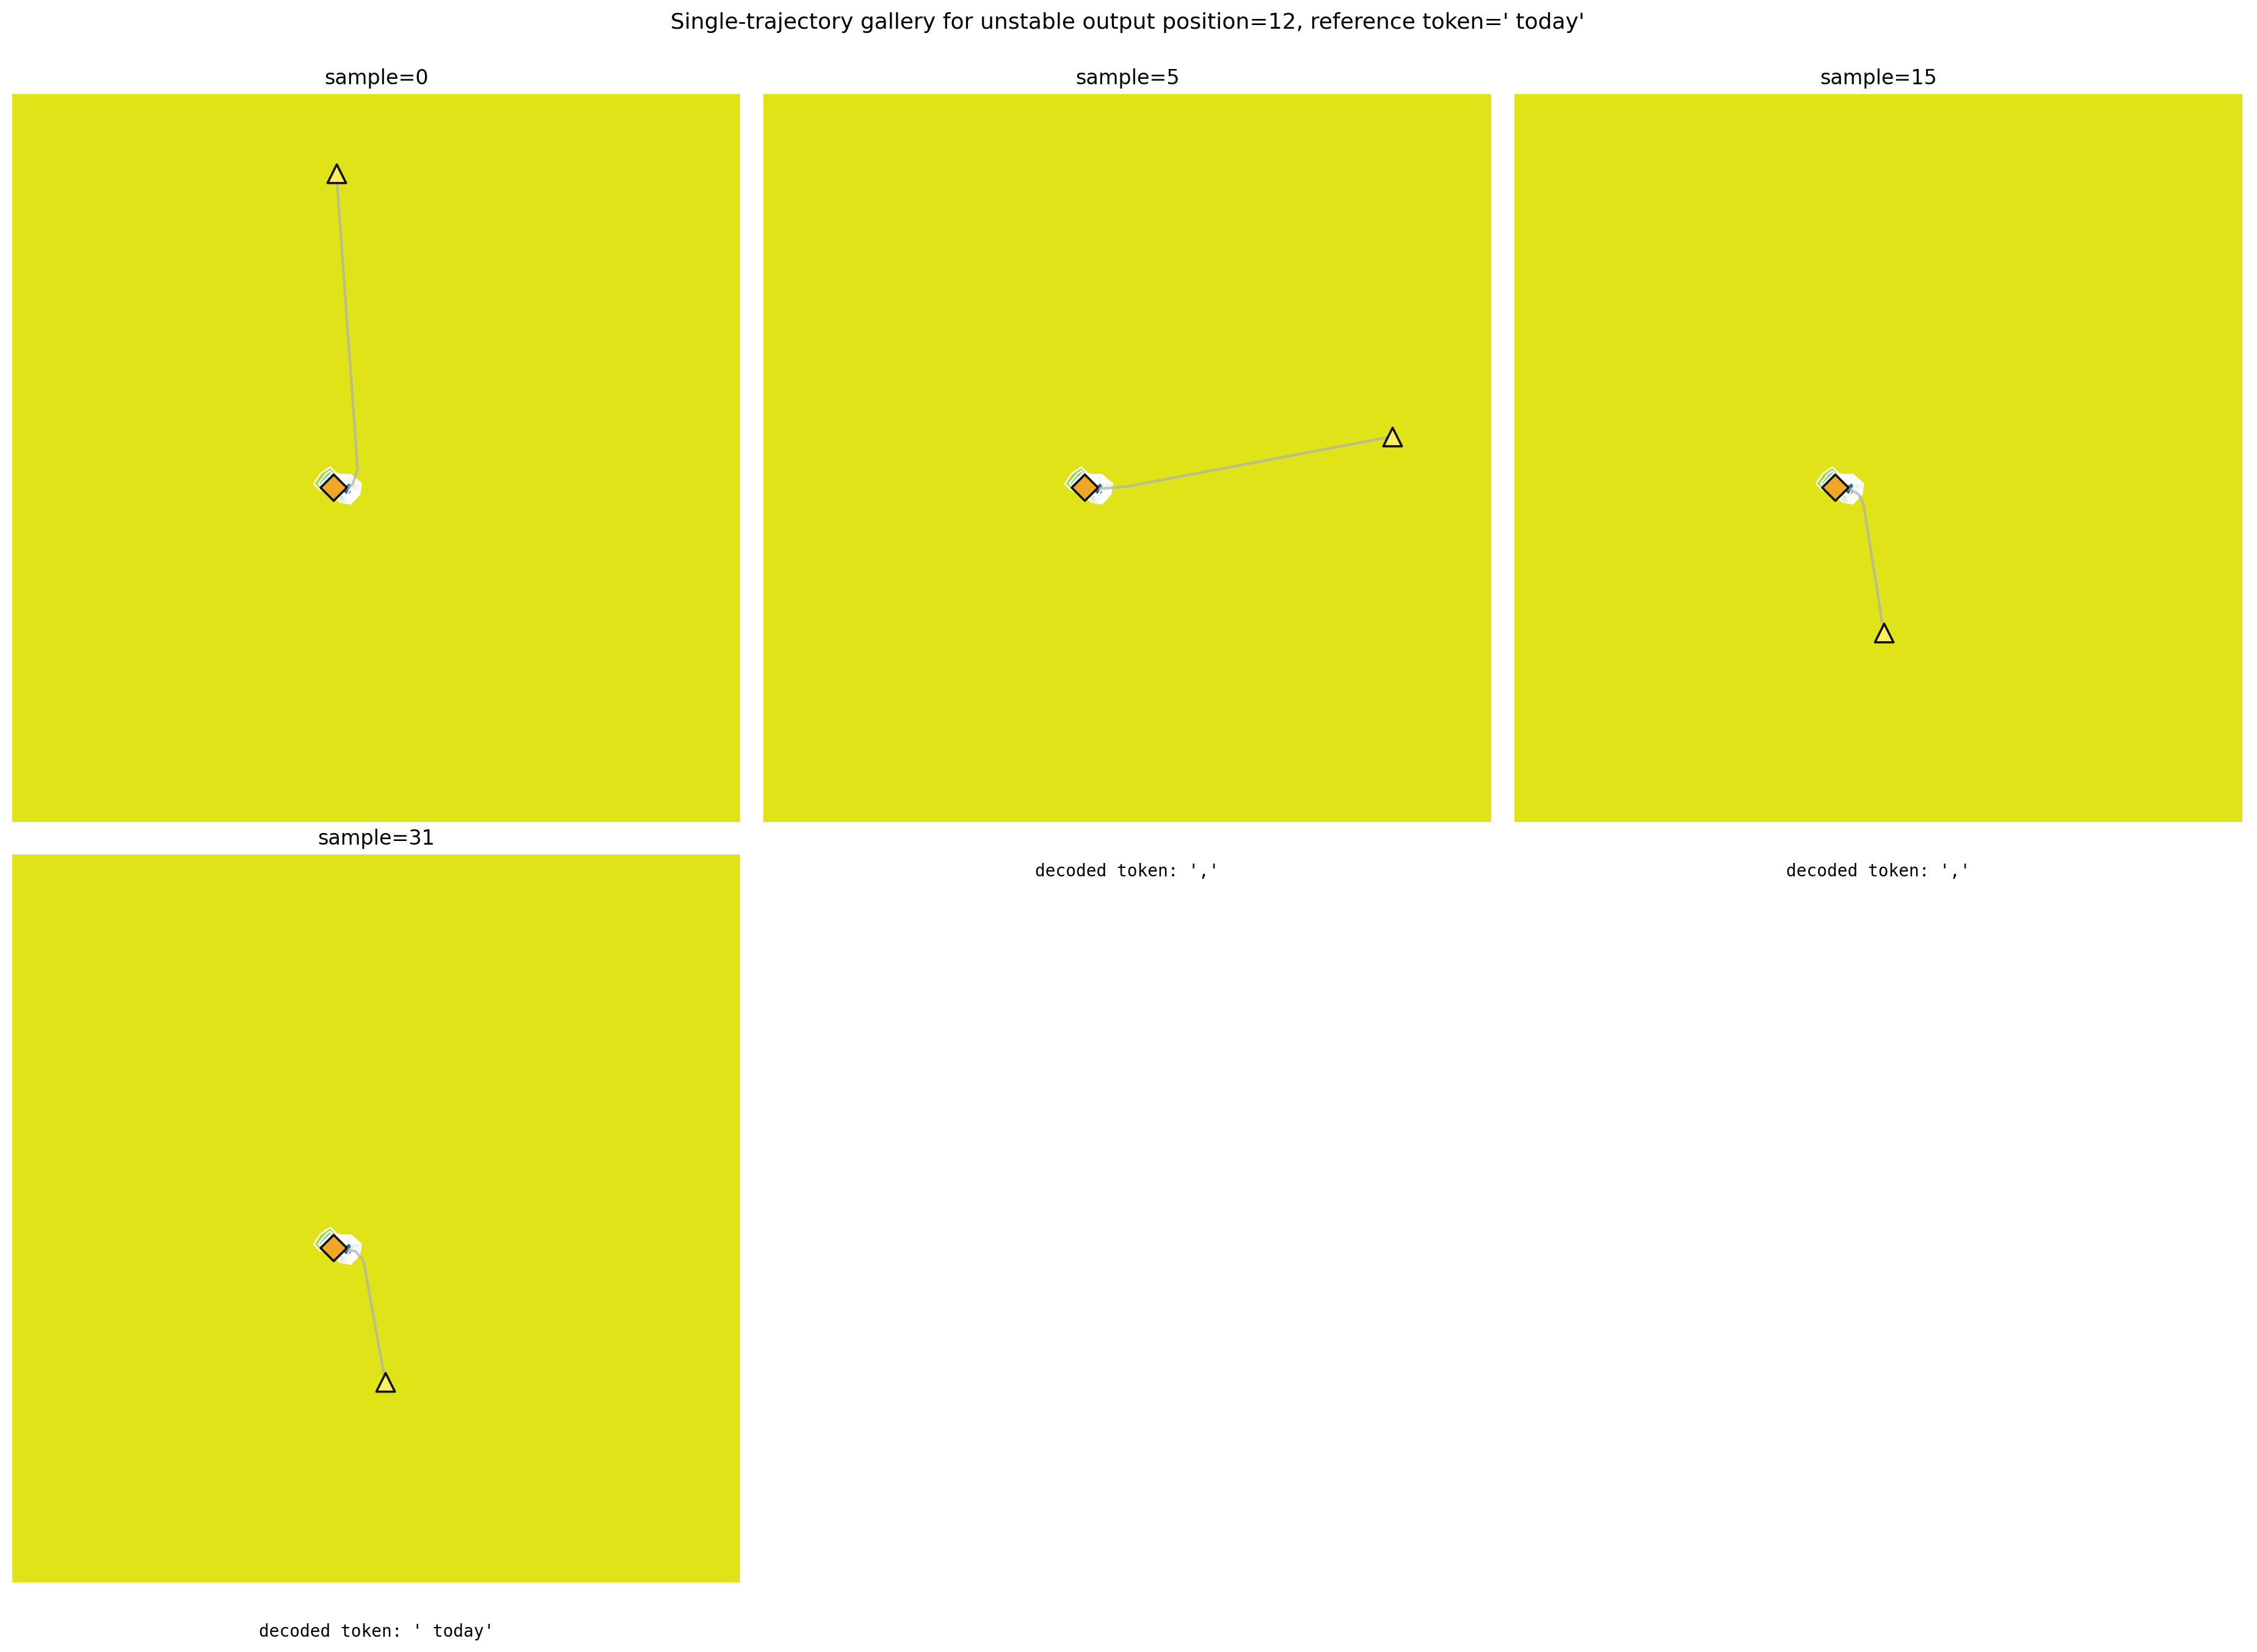


{'unstable_position': 16, 'reference_token': ' use', 'top_tokens': [(' use', 45), (' follow', 3)]}


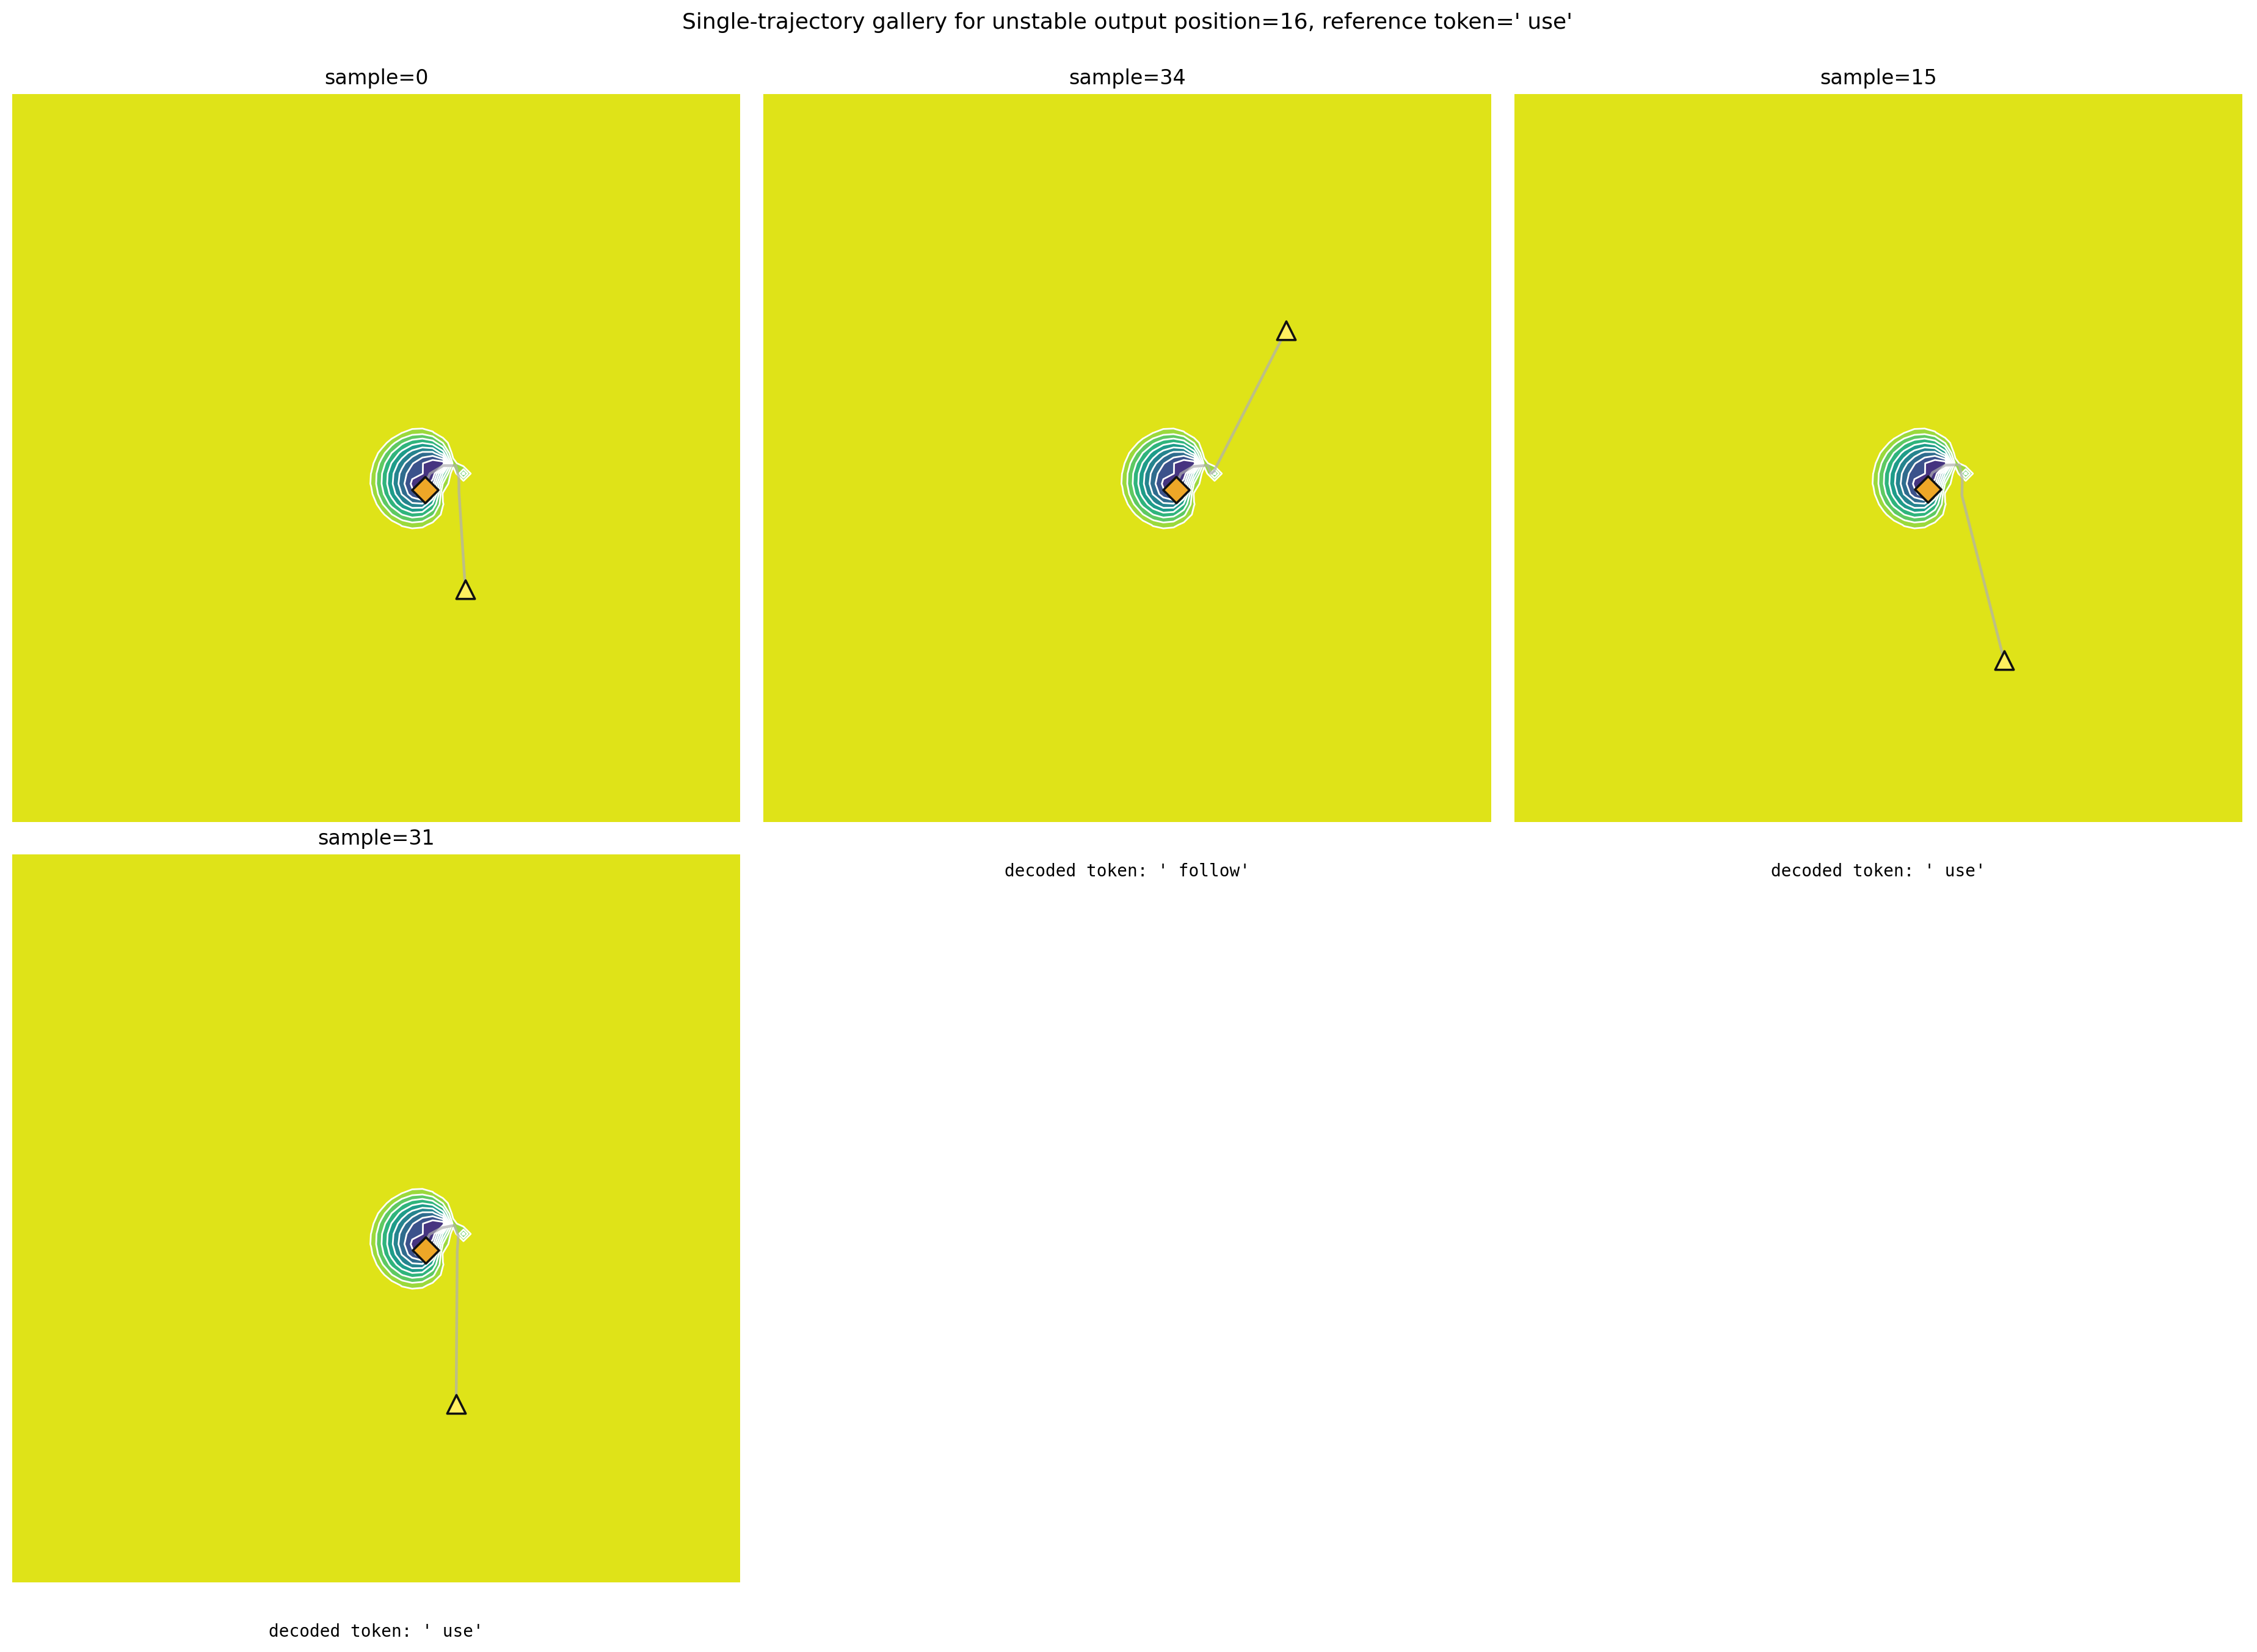


{'unstable_position': 17, 'reference_token': ' a', 'top_tokens': [(' a', 39), (' the', 9)]}


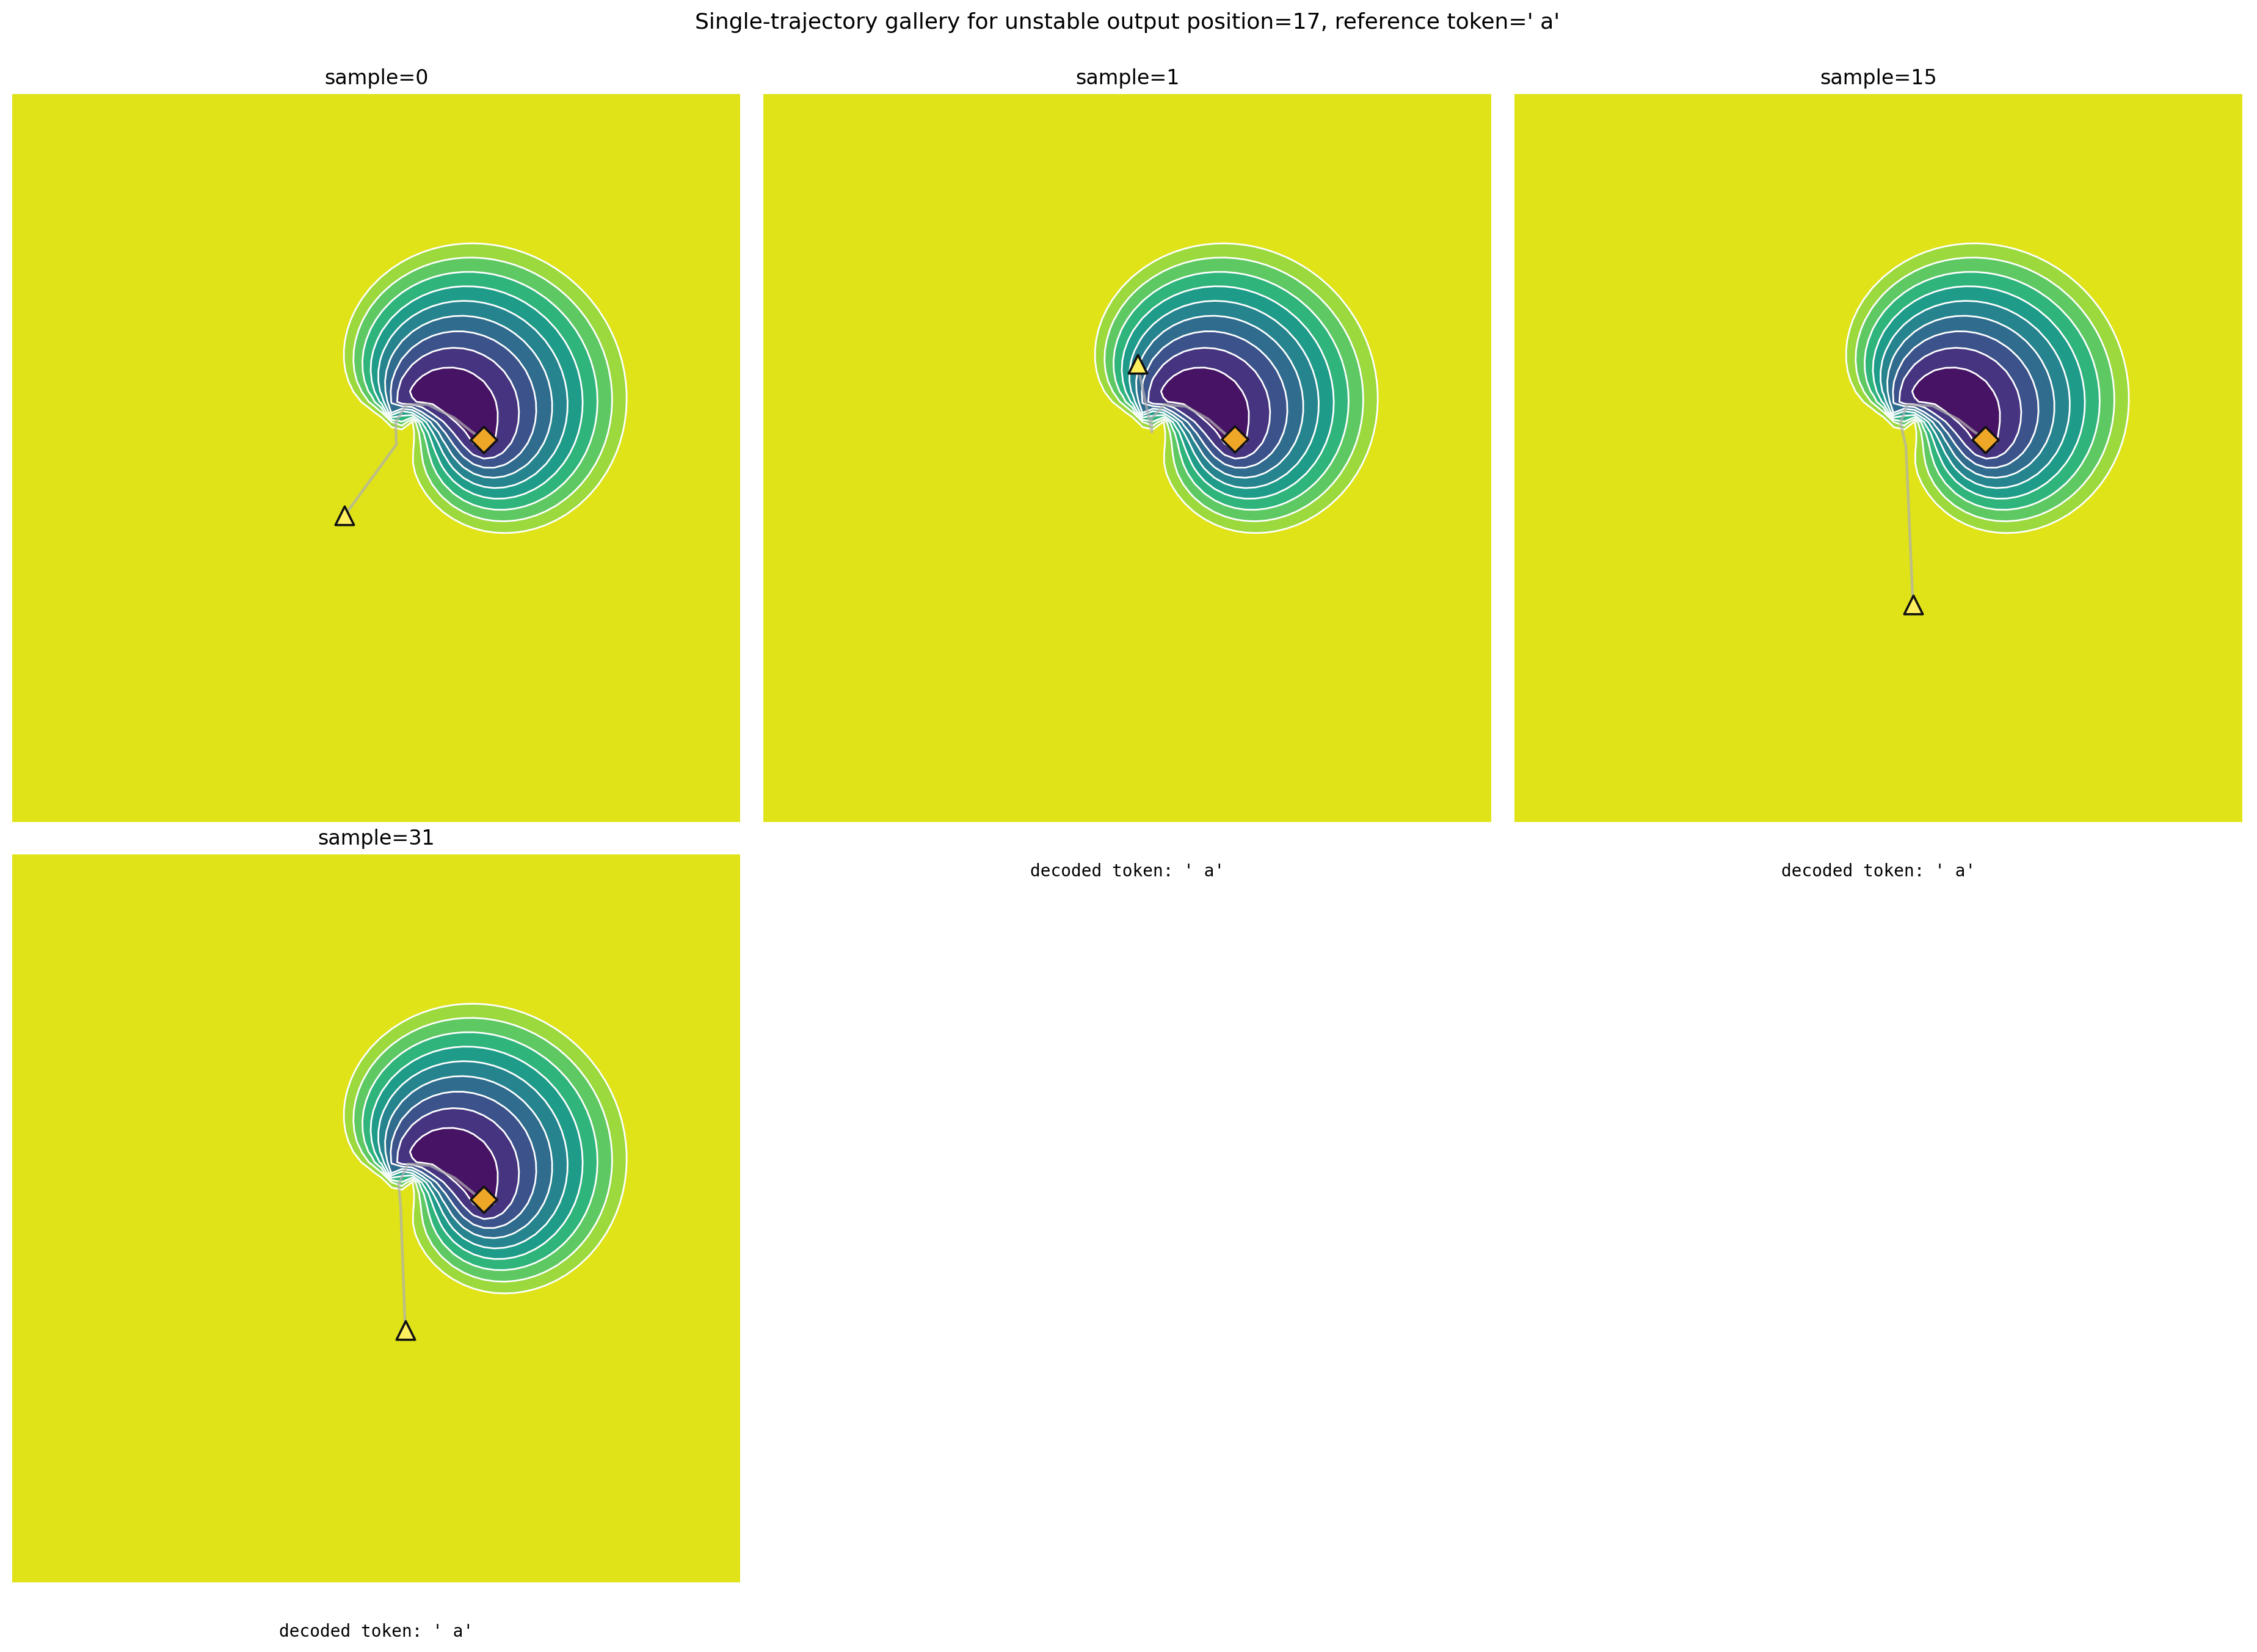

In [35]:
UNSTABLE_GALLERY_MAX_POSITIONS = None  # set an int here if you want to cap the number of plotted unstable positions

def choose_gallery_indices(labels, count):
    chosen = []
    seen = set()
    for idx, label in enumerate(labels):
        if label not in seen:
            chosen.append(idx)
            seen.add(label)
        if len(chosen) == count:
            return chosen

    extras = np.linspace(0, len(labels) - 1, num=min(len(labels), count), dtype=int).tolist()
    for idx in extras:
        if idx not in chosen:
            chosen.append(idx)
        if len(chosen) == count:
            break
    return chosen[:count]

if UNSTABLE_GALLERY_MAX_POSITIONS is None:
    unstable_positions_to_plot = variable_output_positions
else:
    unstable_positions_to_plot = variable_output_positions[:UNSTABLE_GALLERY_MAX_POSITIONS]

if not unstable_positions_to_plot:
    print("No unstable output token found in the scanned prefix, so the galleries are skipped.")
else:
    unstable_gallery_num_samples = max(SINGLE_TRAJECTORY_COUNT, min(NUM_SAMPLES, 48))
    unstable_gallery_batch_size = min(SAMPLE_BATCH_SIZE, 8)
    unstable_gallery_num_steps = min(NUM_STEPS, max(FULL_OUTPUT_NUM_STEPS, SEARCH_NUM_STEPS))
    print({
        "unstable_positions_to_plot": len(unstable_positions_to_plot),
        "gallery_num_samples": unstable_gallery_num_samples,
        "gallery_num_steps": unstable_gallery_num_steps,
    })

    for unstable in unstable_positions_to_plot:
        unstable_position = unstable["position"]
        unstable_reference_token = decode_token_ids(tokenizer, [unstable["reference_token_id"]], max_chars=24)[0]
        if unstable_position == 0:
            unstable_prefix_ids = preview_input_ids
        else:
            unstable_prefix_ids = torch.cat([preview_input_ids, torch.tensor(generated_token_ids[:unstable_position], device=preview_input_ids.device).unsqueeze(0)], dim=-1)

        unstable_gallery_trace = collect_next_token_trajectories(
            model=model,
            input_ids=unstable_prefix_ids,
            num_samples=unstable_gallery_num_samples,
            num_steps=unstable_gallery_num_steps,
            init_scale=analysis_init_scale,
            batch_size=unstable_gallery_batch_size,
        )

        unstable_predicted_token_labels = decode_token_ids(
            tokenizer,
            unstable_gallery_trace["predicted_token_ids"].tolist(),
            max_chars=24,
        )
        unstable_counter = Counter(unstable_predicted_token_labels)
        unstable_states = unstable_gallery_trace["states"].unsqueeze(2)
        unstable_pca = project_states_with_pca(unstable_states, whiten_coords=WHITEN_COORDS)[0]
        unstable_coords = unstable_pca["coords"].numpy()
        unstable_residuals = unstable_gallery_trace["residual_norms"].numpy()

        print()
        print({
            "unstable_position": unstable_position,
            "reference_token": unstable_reference_token,
            "top_tokens": unstable_counter.most_common(8),
        })

        gallery_indices = choose_gallery_indices(unstable_predicted_token_labels, SINGLE_TRAJECTORY_COUNT)
        ncols = min(3, len(gallery_indices))
        nrows = math.ceil(len(gallery_indices) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 6.8 * nrows), dpi=200)
        axes = np.atleast_1d(axes).reshape(nrows, ncols)

        for ax, sample_idx in zip(axes.flat, gallery_indices):
            draw_landscape_with_trajectories(
                ax,
                coords=unstable_coords,
                residuals=unstable_residuals,
                title=f"sample={sample_idx}",
                grid_size=PLOT_GRID_SIZE,
                grid_pad=GRID_PAD,
                smooth=RBF_SMOOTH,
                level_count=CONTOUR_LEVEL_COUNT,
                cmap="viridis",
                hide_axes=HIDE_AXES,
                trajectory_sample_indices=[sample_idx],
                palette=PALETTE,
                                    )
            footer = f"decoded token: {unstable_predicted_token_labels[sample_idx]!r}"
            ax.text(0.5, -0.055, footer, transform=ax.transAxes, ha="center", va="top", fontsize=10, family="monospace")

        for ax in axes.flat[len(gallery_indices):]:
            ax.set_axis_off()

        fig.suptitle(
            f"Single-trajectory gallery for unstable output position={unstable_position}, reference token={unstable_reference_token!r}",
            y=0.995,
            fontsize=13,
        )
        fig.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.show()

## Average Residual Curves

Average residual magnitude over samples for each selected position.

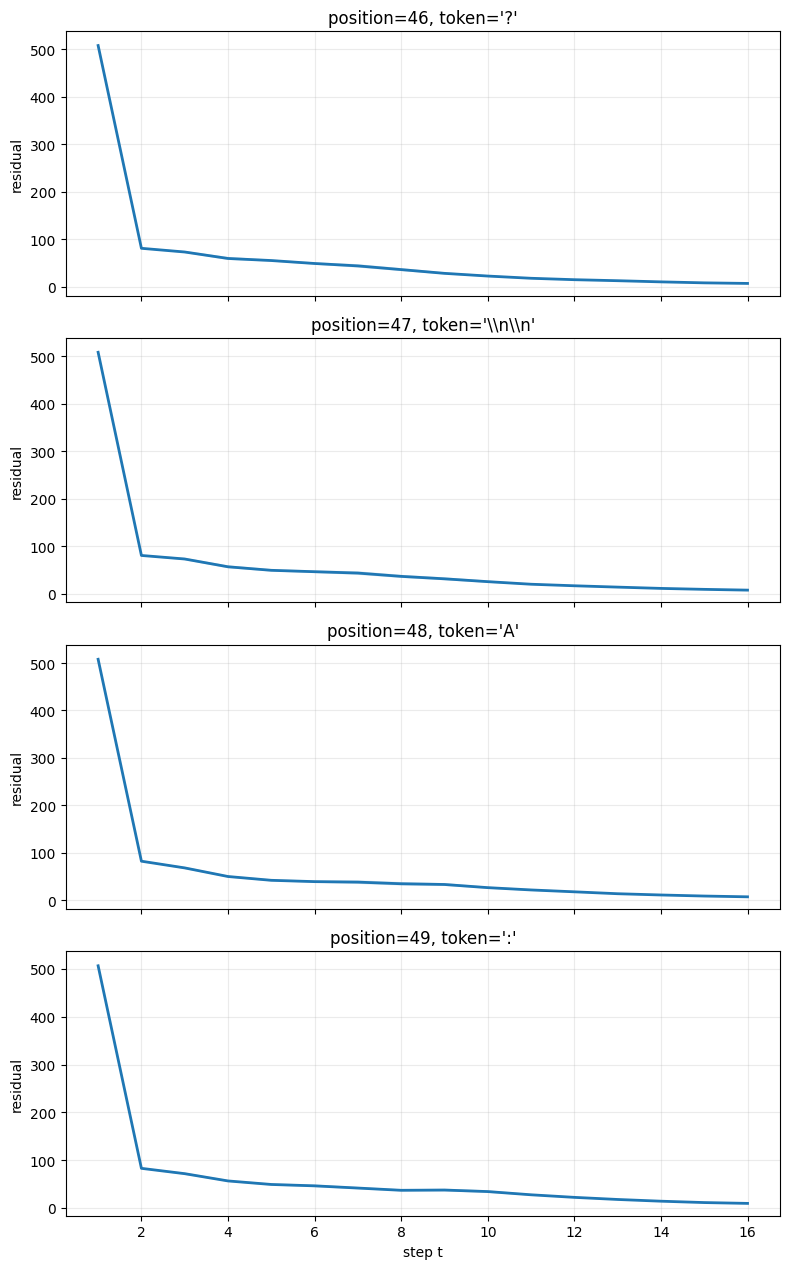

In [36]:
fig, axes = plt.subplots(len(selected_positions), 1, figsize=(8, 3.2 * len(selected_positions)), sharex=True)
if len(selected_positions) == 1:
    axes = [axes]

x = np.arange(1, NUM_STEPS + 1)
for slot, ax in enumerate(axes):
    mean_curve = residual_norms[:, :, slot].mean(dim=0).numpy()
    std_curve = residual_norms[:, :, slot].std(dim=0).numpy()
    ax.plot(x, mean_curve, linewidth=2.0)
    ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)
    ax.set_ylabel("residual")
    ax.set_title(f"position={selected_positions[slot]}, token={selected_labels[slot]!r}")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("step t")
fig.tight_layout()
plt.show()
